모델 배포 개론 07  
Last modified : 2026.08   
작성 : 박광석 (모두의연구소)  
수정 : 김지성 박기웅 (모두의연구소)

In [1]:
# 서버 실행 도우미 — 노트북 맨 처음에 한 번 실행하세요.
# 노트북 안에서 uvicorn 서버를 띄우고 멈추는 함수를 정의합니다.
# Colab의 nest_asyncio 방식 대신, macOS에서도 안정적인 표준 asyncio 루프를 사용합니다.
# LLM 서버는 모델 로드 때문에 기동이 느립니다 — 최대 5분 대기합니다.
print("도우미 로딩 중...", flush=True)

import os, sys, asyncio, threading, time, socket, contextlib, subprocess, signal
from pathlib import Path

print("uvicorn import 중...", flush=True)
import uvicorn
print("uvicorn 준비 완료", flush=True)

cwd = Path.cwd()
if (cwd / "DP07.ipynb").exists() or (cwd / "app").exists():
    pass
elif (cwd / "DP07" / "DP07.ipynb").exists():
    os.chdir(cwd / "DP07")
elif cwd.name == "notebooks" and (cwd.parent / "app").exists():
    os.chdir(cwd.parent)

for _d in ("app", "models", "data", "frontend"):
    os.makedirs(_d, exist_ok=True)

_SERVERS = {}

def _port_open(host, port):
    with contextlib.closing(socket.socket()) as s:
        s.settimeout(0.5)
        return s.connect_ex((host, port)) == 0

def _pids_on_port(port):
    """해당 포트를 LISTEN 중인 프로세스 PID 목록을 반환합니다."""
    try:
        out = subprocess.check_output(
            ["lsof", "-nP", f"-iTCP:{port}", "-sTCP:LISTEN", "-t"],
            text=True,
            stderr=subprocess.DEVNULL,
            timeout=2,
        )
    except (subprocess.CalledProcessError, FileNotFoundError, subprocess.TimeoutExpired):
        return []
    pids = []
    for line in out.split():
        try:
            pid = int(line)
        except ValueError:
            continue
        if pid != os.getpid():
            pids.append(pid)
    return pids

def stop_server(port=8000):
    """실행 중인 서버를 멈춥니다. 같은 포트의 다른 프로세스도 종료합니다."""
    entry = _SERVERS.pop(port, None)
    if entry:
        server, thread = entry
        server.should_exit = True
        for _ in range(50):
            if not thread.is_alive():
                break
            time.sleep(0.1)
    for pid in _pids_on_port(port):
        try:
            os.kill(pid, signal.SIGTERM)
        except ProcessLookupError:
            pass
    for _ in range(50):
        if not _port_open("127.0.0.1", port):
            break
        time.sleep(0.1)

def serve_in_thread(app, host="127.0.0.1", port=8000, log_level="warning"):
    """백그라운드에서 uvicorn 서버를 띄웁니다.

    app: FastAPI 객체 또는 'app.chatbot_api:app' 같은 import 경로.
    같은 포트에 서버가 이미 있으면 먼저 멈추고 새로 띄웁니다.
    LLM은 lifespan에서 모델을 로드하므로 포트가 열릴 때까지 최대 5분 기다립니다.
    """
    stop_server(port)
    if isinstance(app, str):
        sys.modules.pop(app.split(":")[0], None)
    for _ in range(50):
        if not _port_open(host, port):
            break
        time.sleep(0.1)
    if _port_open(host, port):
        print(f"포트 {port}가 아직 사용 중입니다. 다른 서버를 종료한 뒤 다시 실행하세요.")
        return None
    config = uvicorn.Config(app, host=host, port=port, log_level=log_level, loop="asyncio")
    server = uvicorn.Server(config)
    server.install_signal_handlers = lambda: None
    def _run():
        if sys.platform == "win32":
            loop = asyncio.SelectorEventLoop()
        else:
            loop = asyncio.new_event_loop()
        asyncio.set_event_loop(loop)
        loop.run_until_complete(server.serve())
    thread = threading.Thread(target=_run, daemon=True)
    thread.start()
    _SERVERS[port] = (server, thread)
    # 모델 다운로드·로드 포함 — 포트가 열릴 때까지 대기
    for i in range(600):
        if _port_open(host, port):
            print(f"서버 실행됨: http://{host}:{port}")
            return server
        if not thread.is_alive():
            print("서버 스레드가 종료됐습니다. 위 로그를 확인하세요.")
            return server
        if i > 0 and i % 20 == 0:
            print(f"  ... 모델 로드 중 ({i // 2}초 경과)")
        time.sleep(0.5)
    print("5분 내에 서버가 시작되지 않았습니다. 위 로그를 확인하세요.")
    return server

print("서버 도우미 준비 완료 (serve_in_thread, stop_server)", flush=True)
print(f"작업 디렉터리: {Path.cwd()}", flush=True)

도우미 로딩 중...
uvicorn import 중...
uvicorn 준비 완료
서버 도우미 준비 완료 (serve_in_thread, stop_server)
작업 디렉터리: /Users/choiseunghyeon/AIFFEL_Quest_ENG/06_Deployment/DP07


# Day 7 — [프로젝트 2] 트랜스포머 챗봇 서비스



## 1. 프로젝트 개요: 한국어 챗봇 서비스 설계

---

> **학습 목표**
> - 프로젝트 2의 전체 구조와 최종 결과물을 파악합니다.
> - Day 5(정형 데이터 회귀)와 Day 7(텍스트 생성 챗봇)의 차이를 이해합니다.
> - Hugging Face 모델을 서빙하는 구조를 파악합니다.

---



### 1.1 오늘 만들 것

```
[최종 결과물]

브라우저에서:
  1. 채팅 입력란에 메시지를 입력합니다.
  2. 한국어 GPT 모델이 응답을 생성합니다.
  3. 대화 기록이 유지되며 멀티턴 대화가 가능합니다.

내부 구조:
  Streamlit (채팅 UI)
      ↓ HTTP (JSON + API Key)
  FastAPI (인증 → 토크나이징 → 추론 → 디코딩)
      ↓
  Hugging Face Transformers (한국어 GPT 모델)
```



### 1.2 Day 5 vs Day 7 비교

```
                    Day 5 (프로젝트 1)           Day 7 (프로젝트 2)
──────────────────────────────────────────────────────────────
데이터              정형 (숫자 8개)              비정형 (텍스트)
모델                PyTorch MLP                 Hugging Face Transformer
태스크              회귀 (가격 예측)             텍스트 생성 (챗봇)
입력 방식           JSON (숫자)                 JSON (텍스트 + 대화 기록)
인증                없음                        API Key 인증
전처리              정규화 (mean/std)            토크나이저 (BPE)
후처리              숫자 → 가격                  토큰 ID → 텍스트
```



### 1.3 사용할 모델
이번 시간에는 **인스트럭션 튜닝(지시를 따르도록 추가 학습)된** 한국어 가능 모델을 사용합니다.

```
모델: Qwen/Qwen2.5-1.5B-Instruct  (CPU만 있는 환경은 0.5B 버전)
크기: 약 1.5B 파라미터 (다운로드 약 3GB)
특징: 대화(챗) 형식으로 학습되어, 인사엔 인사로 답한다
라이브러리: transformers (Hugging Face)
```

> ⚠️ '베이스 모델'(이어쓰기만 배운 모델)은 챗봇에 쓰면 "하이"에 엉뚱한 텍스트를 이어 붙입니다.  
> 챗봇에는 모델 카드에 **Instruct/Chat** 표기가 있는 모델을 골라야 합니다.  
> 이 교안은 환경(GPU 유무)에 맞게 크기를 자동 선택합니다.


### 1.4 프로젝트 구조

```
model-serving-course/
├── 📁 app/
│   ├── auth.py                ← Day 6 (그대로 사용)
│   ├── chatbot_model.py       ← 🆕 모델 로드 + 텍스트 생성
│   ├── chatbot_schemas.py     ← 🆕 챗봇 API 스키마
│   ├── chatbot_api.py         ← 🆕 챗봇 FastAPI 서버
│   ├── error_handlers.py      ← Day 3
│   ├── logger_config.py       ← Day 3
│   └── middleware.py          ← Day 3
│
├── 📁 frontend/
│   └── app_chatbot.py         ← 🆕 챗봇 Streamlit 대시보드
│
└── ...
```

---

### ✅ 체크포인트

1. Day 5(정형 데이터)와 Day 7(텍스트 생성)에서 전처리가 어떻게 다릅니까?
2. Hugging Face Transformers 라이브러리의 역할은 무엇입니까?

---



## 2. 모델 준비: Hugging Face 한국어 GPT 모델 로드

---

> **학습 목표**
> - Hugging Face에서 사전 학습된 모델을 다운로드하고 로드합니다.
> - 토크나이저와 모델의 역할을 이해합니다.
> - 텍스트 생성 추론을 테스트합니다.

---



### 2.1 패키지 설치

In [2]:
# transformers가 없으면 설치합니다. (Colab은 세션마다 확인이 필요합니다)
import importlib.util, sys, subprocess

for _pkg in ("transformers", "accelerate"):
    if importlib.util.find_spec(_pkg) is None:
        print(f"❌ {_pkg} 미설치 → 지금 설치합니다.")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", _pkg], check=True)

import torch, transformers
print(f"PyTorch: {torch.__version__}")
print(f"Transformers: {transformers.__version__}")
print(f"GPU 사용 가능: {torch.cuda.is_available()}")


PyTorch: 2.4.1
Transformers: 4.49.0
GPU 사용 가능: False


### 2.2 모델 선택 및 로드

In [3]:
from transformers import AutoTokenizer, AutoModelForCausalLM

# 디바이스: NVIDIA GPU(cuda) → Apple Silicon(mps) → CPU 순으로 선택
if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"

# GPU(cuda/mps)면 1.5B, CPU만 있으면 0.5B — 둘 다 '인스트럭션 튜닝' 모델
MODEL_NAME = "Qwen/Qwen2.5-1.5B-Instruct" if DEVICE != "cpu" else "Qwen/Qwen2.5-0.5B-Instruct"
print(f"모델: {MODEL_NAME} ({DEVICE})")
print("모델 다운로드 중... (최초 실행 시 시간이 걸립니다)")

모델: Qwen/Qwen2.5-1.5B-Instruct (mps)
모델 다운로드 중... (최초 실행 시 시간이 걸립니다)


In [4]:
device = DEVICE
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)    # *your code* — 토크나이저 로드
dtype = torch.float16 if device in ("cuda", "mps") else torch.float32
model = AutoModelForCausalLM.from_pretrained(MODEL_NAME, torch_dtype=dtype)  # *your code* — 모델 로드
model = model.to(device)
model.eval()

print(f"✅ 모델 로드 완료")
print(f"파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

Sliding Window Attention is enabled but not implemented for `sdpa`; unexpected results may be encountered.


✅ 모델 로드 완료
파라미터 수: 1,543,714,304


> 토크나이저와 `model.generate()`는 LLM 학습에서 이미 사용해 보셨을 것입니다.
> 여기서는 "이것을 API로 서빙하는 방법"에 집중합니다.

### 2.3 텍스트 생성 테스트

In [5]:
# 단일 프롬프트로 텍스트 생성
prompt = "인공지능의 미래는"

input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)

with torch.no_grad():
    output_ids = model.generate(
        input_ids,
        max_new_tokens=50,           # *your code* — 최대 생성 토큰 수
        temperature=0.8,
        top_k=50,
        top_p=0.9,
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id,
    )

generated_text = tokenizer.decode(output_ids[0], skip_special_tokens=True)
print(f"프롬프트: {prompt}")
print(f"생성 결과: {generated_text}")

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


프롬프트: 인공지능의 미래는
생성 결과: 인공지능의 미래는 빅데이터와 AI로 결정될 수 있습니다. 이 두 가지 기술은 현재까지의 모든 IT 기술에 대해 약 100배 이상의 성능을 보여주는 것으로 알려져 있습니다. 그러나 �


### 2.4 멀티턴 대화 테스트

멀티턴 챗봇의 핵심은 **이전 대화를 프롬프트에 포함**하는 것입니다.
RAG/Agent에서 경험하셨을 패턴과 동일합니다.

In [6]:
# 대화 기록을 하나의 프롬프트로 결합
conversation = [
    "사용자: 안녕하세요!",
    "봇: 안녕하세요! 무엇을 도와드릴까요?",
    "사용자: 오늘 날씨가 어때?",
]

prompt = "\n".join(conversation) + "\n봇:"        # *your code* — 대화 기록 결합

input_ids = tokenizer.encode(prompt, return_tensors="pt").to(device)

with torch.no_grad():
    output_ids = model.generate(
        input_ids, max_new_tokens=50, temperature=0.8,
        top_k=50, do_sample=True, pad_token_id=tokenizer.eos_token_id,
    )

full_response = tokenizer.decode(output_ids[0], skip_special_tokens=True)
bot_response = full_response[len(prompt):].split("사용자:")[0].strip()

print(f"봇 응답: {bot_response}")

봇 응답: 전통적으로 나는 날씨 정보를 제공하는 기능이 없습니다. 하지만 현재 위치에 따라 실시간 날씨 정보를 제공할 수 있습니다. 어떤 지역의 날씨를 원하시나요? 또는, 내일의


> 대화가 길어지면 토큰 수 제한에 걸릴 수 있으므로,
> 섹션 3의 `ChatbotModel`에서 최근 대화만 유지하는 로직을 구현합니다.

---

### ✅ 체크포인트

1. 토크나이저의 `encode()`와 `decode()`는 각각 어떤 변환을 수행합니까?
2. `model.generate()`의 `temperature` 파라미터는 생성 결과에 어떤 영향을 줍니까?
3. 멀티턴 대화에서 이전 대화 기록을 프롬프트에 포함하는 이유는 무엇입니까?

---

> **다음 섹션에서는** 이 추론 로직을 FastAPI 엔드포인트로 만듭니다.


## 3. FastAPI 백엔드: 챗봇 추론 API

---

> **학습 목표**
> - 챗봇용 Pydantic 스키마를 설계합니다 (멀티턴 대화 기록 포함).
> - 텍스트 생성 추론을 FastAPI 엔드포인트로 구현합니다.
> - Swagger UI에서 챗봇 API를 테스트합니다.

---

### 3.1 추론 모듈 작성

In [7]:
%%writefile app/chatbot_model.py
"""
Day 7 - 한국어 챗봇 모델 (인스트럭션 튜닝 모델)
"""
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM


class ChatbotModel:
    """Hugging Face 인스트럭트 모델을 로드하고 대화 응답을 생성합니다."""

    def __init__(self, model_name: str = "Qwen/Qwen2.5-1.5B-Instruct"):
        if torch.cuda.is_available():
            self.device = "cuda"
        elif torch.backends.mps.is_available():
            self.device = "mps"          # Apple Silicon GPU
        else:
            self.device = "cpu"

        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        dtype = torch.float16 if self.device in ("cuda", "mps") else torch.float32
        self.model = AutoModelForCausalLM.from_pretrained(model_name, torch_dtype=dtype)
        self.model = self.model.to(self.device)
        self.model.eval()

        self.model_name = model_name

    def generate_response(
        self,
        messages: list[dict],
        max_new_tokens: int = 100,
        temperature: float = 0.8,
        top_k: int = 50,
        top_p: float = 0.9,
    ) -> str:
        """
        대화 기록을 받아 응답을 생성합니다.

        Args:
            messages: [{"role": "user", "content": "안녕"}, {"role": "bot", "content": "안녕하세요!"}, ...]
            max_new_tokens: 최대 생성 토큰 수
            temperature: 생성 다양성
        Returns:
            생성된 응답 텍스트
        """
        # 대화 기록 → 채팅 템플릿 (모델이 학습한 대화 형식 그대로)
        chat = [{"role": "system",
                 "content": "너는 친절한 한국어 챗봇이야. 반드시 한국어로, 두세 문장으로 자연스럽게 대답해."}]
        for msg in messages:
            role = "user" if msg["role"] == "user" else "assistant"
            chat.append({"role": role, "content": msg["content"]})

        def encode(chat_messages):
            """채팅 기록을 모델 입력 텐서로 만듭니다."""
            encoded = self.tokenizer.apply_chat_template(     # *your code* — 프롬프트 구성
                chat_messages, add_generation_prompt=True, return_tensors="pt"
            )
            # transformers 버전에 따라 Tensor 또는 BatchEncoding(dict)이 반환됩니다.
            # 최신 버전은 후자이므로 input_ids만 꺼내 텐서로 통일합니다.
            if not torch.is_tensor(encoded):
                encoded = encoded["input_ids"]
            return encoded.to(self.device)

        input_ids = encode(chat)

        # 토큰 예산 초과 시 오래된 턴부터 잘라낸다 (모델 최대 길이 초과 방지)
        max_length = getattr(self.model.config, "max_position_embeddings", 2048)
        while input_ids.shape[1] > max_length - max_new_tokens and len(chat) > 2:
            chat.pop(1)                  # system 바로 다음(가장 오래된) 턴 제거
            input_ids = encode(chat)

        # 텍스트 생성
        with torch.no_grad():
            output_ids = self.model.generate(
                input_ids,
                max_new_tokens=max_new_tokens,             # *your code* — 생성 파라미터
                temperature=temperature,
                top_k=top_k,
                top_p=top_p,
                do_sample=True,
                pad_token_id=self.tokenizer.eos_token_id,
            )

        # 생성된 부분만 디코딩 — 인스트럭트 모델은 답이 끝나면 스스로 멈춘다
        response = self.tokenizer.decode(
            output_ids[0][input_ids.shape[1]:], skip_special_tokens=True
        ).strip()

        return response if response else "(응답을 생성하지 못했습니다)"

Writing app/chatbot_model.py


---

### 3.2 Pydantic 스키마

In [8]:
%%writefile app/chatbot_schemas.py
"""
Day 7 - 챗봇 API 스키마
"""
from pydantic import BaseModel, Field
from typing import Optional


class Message(BaseModel):
    """단일 대화 메시지"""
    role: str = Field(..., description="역할: 'user' 또는 'bot'")
    content: str = Field(..., min_length=1, description="메시지 내용")


class ChatRequest(BaseModel):
    """챗봇 요청"""
    messages: list[Message] = Field(
        ...,
        min_length=1,
        description="대화 기록. 마지막 메시지가 사용자의 현재 입력.",
    )
    max_new_tokens: int = Field(default=100, ge=10, le=500)     # *your code* — 범위 제한
    temperature: float = Field(default=0.8, gt=0.0, le=2.0)

    model_config = {
        "json_schema_extra": {
            "examples": [
                {
                    "messages": [
                        {"role": "user", "content": "안녕하세요!"}
                    ],
                    "max_new_tokens": 100,
                    "temperature": 0.8,
                }
            ]
        }
    }


class ChatResponse(BaseModel):
    """챗봇 응답"""
    success: bool = Field(description="성공 여부")
    response: str = Field(description="생성된 응답 텍스트")
    model_name: str = Field(description="사용된 모델")
    user: Optional[str] = Field(default=None, description="인증된 사용자")

Writing app/chatbot_schemas.py


> 핵심 설계:
> - `messages`는 대화 기록 전체를 리스트로 받습니다.
> - 클라이언트가 대화 기록을 관리하고, 매 요청마다 전체 기록을 보냅니다.
> - 서버는 상태를 유지하지 않습니다 (REST의 무상태 원칙 — Day 1에서 배운 것).

---

### 3.3 FastAPI 서버

> ⚠️ **Day 7부터 바로 시작했거나, 로컬에서 DP07만 연 경우**
>
> 아래에서 만들 `chatbot_api.py`는 이전 Day에서 만든 파일들을 import 합니다.
> — `auth.py`(Day 6), `logger_config.py`·`error_handlers.py`·`middleware.py`(Day 3)
> 아래 셀을 실행하면 없는 파일만 자동으로 만들어 줍니다. (이미 있으면 그대로 둡니다)

In [9]:
# 이전 Day에서 만든 파일을 확인하고, 없으면 새로 만듭니다.
# (아래에서 만들 chatbot_api.py 가 이 파일들을 import 합니다)
import os

os.makedirs("app", exist_ok=True)

BACKEND_FILES = {}

BACKEND_FILES["app/auth.py"] = r'''"""
Day 6 - API Key 인증
"""
from fastapi import HTTPException, Header

# API Key 설정
# 실무에서는 환경 변수나 시크릿 매니저에서 로드합니다.
# 여기서는 학습 목적으로 하드코딩합니다.
VALID_API_KEYS = {
    "test-key-001": "사용자A",
    "test-key-002": "사용자B",
}


async def verify_api_key(x_api_key: str = Header(None)) -> str:  # *your code* — Header에서 키 추출
    """
    API Key를 검증합니다.

    동작 원리:
      - FastAPI는 파라미터 이름 x_api_key를 HTTP 헤더 X-API-Key에 자동 매핑합니다.
        (언더스코어 _ → 하이픈 -, 대소문자 무시)
      - Header(None): 헤더가 없으면 None이 들어옵니다.

    Returns:
        인증된 사용자 이름 (예: "사용자A")
    Raises:
        HTTPException(401): 키가 없거나 유효하지 않을 때
    """
    if x_api_key is None:
        raise HTTPException(
            status_code=401,                       # *your code* — Unauthorized
            detail="API Key가 필요합니다. X-API-Key 헤더를 포함해 주세요.",
        )

    if x_api_key not in VALID_API_KEYS:
        raise HTTPException(
            status_code=401,
            detail="유효하지 않은 API Key입니다.",
        )

    return VALID_API_KEYS[x_api_key]  # 사용자 이름 반환'''

BACKEND_FILES["app/logger_config.py"] = r'''"""
Day 3 - 로깅 설정
"""
import logging
import sys


def setup_logger(name: str = "ml_api", level: str = "INFO") -> logging.Logger:
    """콘솔 로거를 설정합니다."""
    logger = logging.getLogger(name)
    logger.setLevel(getattr(logging, level))

    if logger.handlers:
        return logger

    console_handler = logging.StreamHandler(sys.stdout)
    console_handler.setLevel(logging.DEBUG)

    formatter = logging.Formatter(
        fmt="%(asctime)s %(levelname)-8s [%(name)s] %(message)s",
        datefmt="%Y-%m-%d %H:%M:%S",
    )
    console_handler.setFormatter(formatter)
    logger.addHandler(console_handler)

    return logger'''

BACKEND_FILES["app/error_handlers.py"] = r'''"""
Day 3 - 글로벌 에러 핸들러
"""
import traceback
import logging

from fastapi import FastAPI, Request
from fastapi.responses import JSONResponse

logger = logging.getLogger("ml_api")


def register_error_handlers(app: FastAPI):
    """FastAPI 앱에 글로벌 에러 핸들러를 등록합니다."""

    @app.exception_handler(Exception)
    async def general_error_handler(request: Request, exc: Exception):
        """모든 예외를 잡아서 안전한 응답을 반환합니다."""
        logger.error(
            f"에러 발생: {type(exc).__name__}: {exc}\n"
            f"경로: {request.method} {request.url}\n"
            f"스택 트레이스:\n{traceback.format_exc()}"
        )
        return JSONResponse(
            status_code=500,
            content={
                "success": False,
                "error": "서버 내부 오류가 발생했습니다.",
            }
            # ⚠️ 클라이언트에게는 상세 정보를 노출하지 않습니다.
            # 상세 정보는 서버 로그에만 기록됩니다.
        )'''

BACKEND_FILES["app/middleware.py"] = r'''"""
Day 3 - 요청/응답 로깅 미들웨어
모든 요청의 메서드, 경로, 응답 시간, 상태 코드를 자동 로깅합니다.
"""
import time
import logging
from fastapi import Request
from starlette.middleware.base import BaseHTTPMiddleware

logger = logging.getLogger("ml_api")


class RequestLoggingMiddleware(BaseHTTPMiddleware):
    async def dispatch(self, request: Request, call_next):
        start_time = time.time()
        response = await call_next(request)
        duration = round(time.time() - start_time, 3)

        log_message = (
            f"{request.method} {request.url.path} "
            f"→ {response.status_code} "
            f"({duration}s)"
        )

        if response.status_code >= 500:
            logger.error(log_message)
        elif response.status_code >= 400:
            logger.warning(log_message)
        else:
            logger.info(log_message)

        response.headers["X-Process-Time"] = str(duration)
        return response'''

for _path, _body in BACKEND_FILES.items():
    if os.path.exists(_path):
        print(f"✅ {_path} 있음")
    else:
        print(f"⚠️ {_path} 없음 → 생성합니다.")
        with open(_path, "w", encoding="utf-8") as f:
            f.write(_body)

print("\n🎉 준비 완료. 다음 셀로 진행하세요.")


⚠️ app/auth.py 없음 → 생성합니다.
⚠️ app/logger_config.py 없음 → 생성합니다.
⚠️ app/error_handlers.py 없음 → 생성합니다.
⚠️ app/middleware.py 없음 → 생성합니다.

🎉 준비 완료. 다음 셀로 진행하세요.


In [11]:
%%writefile app/chatbot_api.py
"""
Day 7 - 한국어 챗봇 FastAPI 서버
"""
import asyncio
from contextlib import asynccontextmanager
from concurrent.futures import ThreadPoolExecutor

from fastapi import FastAPI, Depends, HTTPException

from app.chatbot_schemas import ChatRequest, ChatResponse
from app.chatbot_model import ChatbotModel
from app.auth import verify_api_key
from app.logger_config import setup_logger
from app.error_handlers import register_error_handlers
from app.middleware import RequestLoggingMiddleware


# ===== 설정 =====
logger = setup_logger("chatbot_api")

inference_executor = ThreadPoolExecutor(max_workers=2, thread_name_prefix="chatbot")

# ===== 모델 로드 =====
chatbot = None


# 서버 생애주기(lifespan) — 시작 시 모델을 한 번 로드합니다.
# (구버전 @app.on_event("startup")는 최신 FastAPI에서 deprecated → lifespan으로 대체)
@asynccontextmanager
async def lifespan(app: FastAPI):
    global chatbot
    import torch
    use_gpu = torch.cuda.is_available() or torch.backends.mps.is_available()
    model_name = "Qwen/Qwen2.5-1.5B-Instruct" if use_gpu else "Qwen/Qwen2.5-0.5B-Instruct"
    logger.info(f"챗봇 모델 로드 중: {model_name}")
    chatbot = ChatbotModel(model_name)                # *your code* — ChatbotModel 인스턴스 생성
    logger.info("모델 로드 완료")
    yield
    # 종료 시 정리할 자원이 있으면 여기에 작성합니다.


app = FastAPI(
    title="Korean Chatbot API",
    description="한국어 GPT 기반 멀티턴 챗봇 API (인증 필요)",
    version="1.0.0",
    lifespan=lifespan,
)

app.add_middleware(RequestLoggingMiddleware)
register_error_handlers(app)


def run_chat(messages, max_new_tokens, temperature):
    """별도 스레드에서 실행되는 추론 함수"""
    if chatbot is None:
        raise RuntimeError("모델이 로드되지 않았습니다")
    return chatbot.generate_response(
        messages=[m.model_dump() for m in messages],
        max_new_tokens=max_new_tokens,
        temperature=temperature,
    )


# ===== 엔드포인트 =====

@app.get("/health", tags=["System"])
async def health_check():
    return {
        "status": "healthy" if chatbot else "loading",
        "model": chatbot.model_name if chatbot else None,
    }


@app.post("/chat", response_model=ChatResponse, tags=["Chat"])
async def chat(
    request: ChatRequest,
    user: str = Depends(verify_api_key),              # *your code* — 인증 적용
):
    """대화 기록을 받아 응답을 생성합니다."""
    if chatbot is None:
        raise HTTPException(status_code=503, detail="모델이 아직 로드되지 않았습니다.")

    logger.info(f"채팅 요청 — 사용자: {user}, 메시지 수: {len(request.messages)}")

    try:
        loop = asyncio.get_running_loop()
        response_text = await loop.run_in_executor(    # *your code* — 비동기 추론
            inference_executor,
            run_chat,
            request.messages,
            request.max_new_tokens,
            request.temperature,
        )
    except Exception as e:
        raise HTTPException(status_code=500, detail=f"텍스트 생성 실패: {str(e)}")

    return ChatResponse(
        success=True,
        response=response_text,
        model_name=chatbot.model_name,
        user=user,
    )

Overwriting app/chatbot_api.py


---

### 3.4 서버 실행 및 테스트

In [12]:
import requests   # 아래 테스트 셀들에서 사용합니다

# 서버 실행 (같은 포트에 서버가 떠 있으면 자동으로 멈추고 새로 띄웁니다)
serve_in_thread("app.chatbot_api:app", port=8000)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


2026-08-21 10:51:29 INFO     [chatbot_api] 챗봇 모델 로드 중: Qwen/Qwen2.5-1.5B-Instruct
  ... 모델 로드 중 (10초 경과)
2026-08-21 10:51:39 INFO     [chatbot_api] 모델 로드 완료
서버 실행됨: http://127.0.0.1:8000


In [13]:
# 헬스체크
resp = requests.get("http://localhost:8000/health")
print(f"헬스체크: {resp.json()}")

헬스체크: {'status': 'healthy', 'model': 'Qwen/Qwen2.5-1.5B-Instruct'}


In [14]:
# 싱글턴 대화 테스트
resp = requests.post(
    "http://localhost:8000/chat",
    json={
        "messages": [
            {"role": "user", "content": "안녕하세요!"}
        ],
    },
    headers={"X-API-Key": "test-key-001"},
)
result = resp.json()
print(f"상태: {resp.status_code}")
print(f"응답: {result['response']}")

2026-08-21 10:51:49 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 1
상태: 200
응답: 안녕하세요! 어떻게 도와드릴까요?


In [15]:
# 멀티턴 대화 테스트
resp = requests.post(
    "http://localhost:8000/chat",
    json={
        "messages": [
            {"role": "user", "content": "안녕하세요!"},
            {"role": "bot", "content": result["response"]},    # 이전 응답 포함
            {"role": "user", "content": "오늘 뭐 하면 좋을까?"},  # *your code* — 새 메시지
        ],
    },
    headers={"X-API-Key": "test-key-001"},
)
result2 = resp.json()
print(f"멀티턴 응답: {result2['response']}")

2026-08-21 10:51:58 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 3
멀티턴 응답: 네, 좋은 날씨에 편안하게 보내고 싶다면, 나무 아래에서 책을 읽거나 푸드 파티를 준비하거나 음악을 듣는 것도 좋을 것 같습니다. 취미 활동도 생각해보세요. 좋아하는 재미있는 것을 찾아보시길 바랍니다.


---

### ✅ 체크포인트

1. `ChatRequest`의 `messages`가 리스트인 이유는 무엇입니까?
2. 서버가 대화 기록을 저장하지 않고, 클라이언트가 매번 전체 기록을 보내는 이유는?
3. `max_new_tokens`을 너무 크게 설정하면 어떤 문제가 발생할 수 있습니까?

---

> **다음 섹션에서는** Streamlit으로 채팅 UI를 만들어 이 API와 연결합니다.


## 4. Streamlit UI: 채팅 인터페이스

---

> **학습 목표**
> - Streamlit의 `st.chat_message`, `st.chat_input`으로 채팅 UI를 구현합니다.
> - `st.session_state`로 대화 기록을 관리합니다.
> - API Key 인증을 UI에 통합합니다.

---

### 4.1 대시보드 코드 작성

In [16]:
%%writefile frontend/app_chatbot.py
"""
Day 7 - 한국어 GPT 챗봇 대시보드
"""
import streamlit as st
import requests


# ===== 페이지 설정 =====
st.set_page_config(
    page_title="한국어 챗봇",
    page_icon="💬",
    layout="centered",
)

API_BASE = "http://localhost:8000"


# ===== API 호출 =====
def call_chat_api(messages, api_key, max_new_tokens=100, temperature=0.8):
    """챗봇 API를 호출합니다."""
    try:
        resp = requests.post(
            f"{API_BASE}/chat",
            json={
                "messages": messages,
                "max_new_tokens": max_new_tokens,
                "temperature": temperature,
            },
            headers={"X-API-Key": api_key},            # *your code* — 인증 헤더
            timeout=60,   # 텍스트 생성은 시간이 걸릴 수 있음
        )
        resp.raise_for_status()
        return resp.json()
    except requests.exceptions.ConnectionError:
        st.error("🔌 **서버에 연결할 수 없습니다.**")
        return None
    except requests.exceptions.HTTPError as e:
        if e.response.status_code == 401:
            st.error("🔑 **인증 실패.** API Key를 확인하세요.")
        else:
            st.error(f"❌ **서버 에러** (HTTP {e.response.status_code})")
        return None
    except Exception as e:
        st.error(f"❌ **오류:** {type(e).__name__}")
        return None


# ===== 사이드바 =====
with st.sidebar:
    st.header("⚙️ 설정")

    api_key = st.text_input("API Key", value="test-key-001", type="password")

    st.divider()

    max_tokens = st.slider("최대 생성 토큰", 10, 300, 100, step=10)
    temperature = st.slider("Temperature", 0.1, 2.0, 0.8, step=0.1)

    st.divider()

    # 서버 상태
    try:
        health = requests.get(f"{API_BASE}/health", timeout=3).json()
        if health.get("status") == "healthy":
            st.success(f"🟢 서버 연결됨")
            st.caption(f"모델: {health.get('model', 'N/A')}")
        else:
            st.warning("🟡 모델 로딩 중...")
    except Exception:
        st.error("🔴 서버 연결 실패")

    st.divider()

    if st.button("대화 초기화"):
        st.session_state["chat_messages"] = []         # *your code* — 대화 기록 초기화
        st.rerun()

    st.caption("Korean GPT Chatbot v1.0")


# ===== 대화 기록 초기화 =====
if "chat_messages" not in st.session_state:
    st.session_state["chat_messages"] = []


# ===== 메인 영역 =====
st.title("💬 한국어 챗봇")
st.write("한국어 GPT 모델과 대화해 보세요.")

# 기존 대화 기록 표시
for msg in st.session_state["chat_messages"]:
    with st.chat_message(msg["role"]):                 # *your code* — 채팅 메시지 표시
        st.write(msg["content"])

# 사용자 입력
user_input = st.chat_input("메시지를 입력하세요...")     # *your code* — 채팅 입력란

if user_input:
    # 사용자 메시지 추가 및 표시
    st.session_state["chat_messages"].append({
        "role": "user",
        "content": user_input,
    })
    with st.chat_message("user"):
        st.write(user_input)

    # API 호출
    with st.chat_message("assistant"):
        with st.spinner("생성 중..."):
            # 대화 기록을 API 형식으로 변환
            api_messages = []
            for msg in st.session_state["chat_messages"]:
                role = "user" if msg["role"] == "user" else "bot"
                api_messages.append({"role": role, "content": msg["content"]})

            result = call_chat_api(
                messages=api_messages,
                api_key=api_key,
                max_new_tokens=max_tokens,
                temperature=temperature,
            )

        if result and result.get("success"):
            bot_response = result["response"]
            st.write(bot_response)

            # 봇 응답을 대화 기록에 추가
            st.session_state["chat_messages"].append({
                "role": "assistant",
                "content": bot_response,
            })
        else:
            st.write("응답을 생성하지 못했습니다.")

Writing frontend/app_chatbot.py


---

### 4.2 Day 4 대시보드와의 핵심 차이

```
Day 4/5 대시보드:
  - st.button() → 클릭하면 요청
  - 결과를 st.metric()으로 표시
  - 단발성 요청/응답

Day 7 챗봇 대시보드:
  - st.chat_input() → 엔터 치면 요청
  - 결과를 st.chat_message()로 표시
  - 대화 기록이 st.session_state에 누적
  - 매 요청마다 전체 대화 기록을 API에 전송
```

> Streamlit의 `st.chat_message`와 `st.chat_input`은
> ChatGPT 스타일의 채팅 UI를 몇 줄의 코드로 만들어줍니다.

---



### ✅ 체크포인트

1. `st.chat_message`와 `st.chat_input`은 각각 어떤 역할을 합니까?
2. `st.session_state["chat_messages"]`에 대화 기록을 저장하는 이유는?
3. "대화 초기화" 버튼이 `st.rerun()`을 호출하는 이유는 무엇입니까?

---

> **다음 섹션에서는** API Key 인증과 에러 처리 흐름을 정리합니다.


## 5. API Key 인증 적용 및 에러 처리

---

> Day 6에서 구현한 인증 모듈(`app/auth.py`)을 그대로 사용합니다.

### 5.1 챗봇에서의 인증 흐름

```
사용자가 사이드바에서 API Key 입력
  ↓
채팅 입력란에 메시지 입력 + 엔터
  ↓
call_chat_api()가 headers={"X-API-Key": api_key} 포함하여 요청
  ↓
서버 verify_api_key() 실행
  ├─ 성공 → 텍스트 생성 → 응답
  └─ 실패 → 401 → "🔑 인증 실패" 표시
```

> 인증 로직은 Day 6과 동일합니다.
> 차이점은 요청 데이터가 이미지(UploadFile)에서 텍스트(JSON)로 바뀐 것뿐입니다.

---



### ✅ 체크포인트

1. 챗봇 API에서 인증이 실패하면 서버는 어떤 상태 코드를 반환합니까?
2. UI의 `call_chat_api()`는 401 응답을 받으면 사용자에게 무엇을 보여줍니까?
3. Day 6의 인증 모듈(`app/auth.py`)을 Day 7에서 수정 없이 재사용할 수 있는 이유는 무엇입니까?

---

> **다음 섹션에서는** 전체 서비스를 통합 테스트합니다.


## 6. 통합 테스트 + Day 7 요약

---

> **실습 목표**
> - 전체 서비스(인증 → 텍스트 생성 → 채팅 UI)를 체계적으로 테스트합니다.
> - 정상/인증 실패/긴 대화/동시 요청 등 다양한 시나리오를 검증합니다.

---

### 6.1 실행 환경 준비

In [17]:
# 서버 실행 (같은 포트에 서버가 떠 있으면 자동으로 멈추고 새로 띄웁니다)
serve_in_thread("app.chatbot_api:app", port=8000)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


2026-08-21 10:52:45 INFO     [chatbot_api] 챗봇 모델 로드 중: Qwen/Qwen2.5-1.5B-Instruct
2026-08-21 10:52:54 INFO     [chatbot_api] 모델 로드 완료
서버 실행됨: http://127.0.0.1:8000


In [18]:
# Streamlit은 .venv에 설치되어 있으면 pip를 건너뜁니다.
import importlib.util
import sys
import subprocess
import time
import socket
import contextlib
import tempfile
import os
import webbrowser

try:
    from google.colab import output as _colab_output
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if importlib.util.find_spec("streamlit") is None:
    print("Streamlit 미설치 → 지금 설치합니다.")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "streamlit"])
else:
    print("Streamlit 이미 설치됨")

def run_streamlit(script, port=8501):
    """Streamlit을 백그라운드로 띄우고 포트가 열릴 때까지 확인합니다."""
    def port_open(p):
        with contextlib.closing(socket.socket()) as s:
            s.settimeout(0.5)
            return s.connect_ex(("127.0.0.1", p)) == 0

    if port_open(port):
        print(f"♻️  이미 실행 중 (포트 {port})")
        return None

    log_path = os.path.join(tempfile.gettempdir(), f"streamlit_{port}.log")
    log = open(log_path, "w", encoding="utf-8")

    extra = []
    if IN_COLAB:
        extra = [
            "--server.enableCORS", "false",
            "--server.enableXsrfProtection", "false",
        ]

    proc = subprocess.Popen(
        [sys.executable, "-m", "streamlit", "run", script,
         "--server.port", str(port),
         "--server.headless", "true",
         *extra],
        stdout=log, stderr=subprocess.STDOUT,
    )
    for _ in range(60):
        if proc.poll() is not None:
            log.close()
            print(f"❌ Streamlit이 종료됨 (code {proc.returncode}) — 로그:")
            print(open(log_path, encoding="utf-8").read()[-2000:])
            return proc
        if port_open(port):
            url = f"http://localhost:{port}"
            print(f"✅ 프론트엔드: {url}")
            print(f"   (로그: {log_path})")
            if not IN_COLAB:
                webbrowser.open(url)
            return proc
        time.sleep(0.25)
    proc.terminate(); log.close()
    print("❌ 15초 내에 포트가 열리지 않음 — 로그:")
    print(open(log_path, encoding="utf-8").read()[-2000:])
    return proc

proc = run_streamlit("frontend/app_chatbot.py", port=8501)

Streamlit 이미 설치됨


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


✅ 프론트엔드: http://localhost:8501
   (로그: /var/folders/pz/kxyvptf55r59t4ktwsn_rhfc0000gn/T/streamlit_8501.log)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


#### 노트북에서 바로 확인

Colab에서는 챗봇 UI를 노트북 iframe으로 띄웁니다.  
로컬(Mac)에서는 `http://localhost:8501` 을 브라우저에서 엽니다.

> ⚠️ **화면이 비어 있거나 계속 로딩만 된다면**
> - 위 셀이 `✅`를 출력했는지 먼저 확인하세요.
> - 로컬에서는 Jupyter iframe 대신 브라우저 탭을 사용하세요.
> - 사이드바가 🔴이면 백엔드 서버 셀을 다시 실행하세요. (모델 로드에 시간이 걸립니다)

In [19]:
def show_dashboard(port=8501, height=900):
    """실행 중인 프론트엔드를 엽니다. Colab은 iframe, 로컬은 브라우저."""
    def port_open(p):
        with contextlib.closing(socket.socket()) as s:
            s.settimeout(0.5)
            return s.connect_ex(("127.0.0.1", p)) == 0

    if not port_open(port):
        print(f"⚠️ 포트 {port}에 프론트엔드가 없습니다. Step 2(Streamlit) 셀을 먼저 실행하세요.")
        return

    if IN_COLAB:
        from google.colab import output
        print(f"✅ 챗봇 UI를 아래에 띄웁니다 (Colab 프록시 → 포트 {port})")
        output.serve_kernel_port_as_iframe(port, height=str(height))
    else:
        import webbrowser
        url = f"http://localhost:{port}"
        print(f"✅ 브라우저에서 엽니다: {url}")
        print("   (Jupyter iframe은 localhost X-Frame 제한으로 비어 보일 수 있습니다)")
        webbrowser.open(url)

show_dashboard(port=8501, height=900)

✅ 브라우저에서 엽니다: http://localhost:8501
   (Jupyter iframe은 localhost X-Frame 제한으로 비어 보일 수 있습니다)


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


---

### 6.2 API 레벨 통합 테스트

In [20]:
import requests, json

API_BASE = "http://localhost:8000"
VALID_KEY = "test-key-001"

print("=" * 60)
print("  통합 테스트")
print("=" * 60)

  통합 테스트


#### 테스트 1: 인증

In [21]:
print("\n[테스트 1] 인증")

# 인증 없이
resp = requests.post(f"{API_BASE}/chat",
    json={"messages": [{"role": "user", "content": "안녕"}]})
print(f"  인증 없음    → HTTP {resp.status_code}")

# 잘못된 키
resp = requests.post(f"{API_BASE}/chat",
    json={"messages": [{"role": "user", "content": "안녕"}]},
    headers={"X-API-Key": "wrong-key"})
print(f"  잘못된 키    → HTTP {resp.status_code}")

# 올바른 키
resp = requests.post(f"{API_BASE}/chat",
    json={"messages": [{"role": "user", "content": "안녕"}]},
    headers={"X-API-Key": VALID_KEY})
print(f"  올바른 키    → HTTP {resp.status_code}")
if resp.status_code == 200:
    print(f"  응답: {resp.json()['response'][:50]}...")

POST /chat → 401 (0.007s)
POST /chat → 401 (0.001s)



[테스트 1] 인증
  인증 없음    → HTTP 401
  잘못된 키    → HTTP 401
2026-08-21 10:57:24 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 1
  올바른 키    → HTTP 200
  응답: 안녕하세요! 어떻게 도와드릴까요?...


#### 테스트 2: 멀티턴 대화

In [22]:
print("\n[테스트 2] 멀티턴 대화")

messages = []
turns = ["안녕하세요!", "오늘 뭐 하면 좋을까?", "맛있는 거 추천해줘"]

for user_msg in turns:
    messages.append({"role": "user", "content": user_msg})

    resp = requests.post(f"{API_BASE}/chat",
        json={"messages": messages, "max_new_tokens": 50},
        headers={"X-API-Key": VALID_KEY})

    result = resp.json()
    bot_msg = result["response"]
    messages.append({"role": "bot", "content": bot_msg})    # *your code* — 봇 응답 추가

    print(f"  사용자: {user_msg}")
    print(f"  봇:    {bot_msg[:60]}...")
    print()

print(f"  총 대화 턴: {len(messages) // 2}")


[테스트 2] 멀티턴 대화
2026-08-21 11:03:35 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 1
  사용자: 안녕하세요!
  봇:    안녕하세요! 어떻게 도와드릴까요?...

2026-08-21 11:03:54 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 3
  사용자: 오늘 뭐 하면 좋을까?
  봇:    오늘 날씨가 좋아 보여서 키즈테니리아에 가볼 수 있을 것 같아요. 그리고 저녁에는 안마사실去看看 어떨까요? ...

2026-08-21 11:04:43 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 5
  사용자: 맛있는 거 추천해줘
  봇:    오늘은 한식에 집중하자면 '불고기', '삼겹살', '비빔밥' 등등 맛집들이 많습니다. 하지만 개인의 취향이 ...

  총 대화 턴: 3


#### 테스트 3: 입력 검증

In [23]:
print("[테스트 3] 입력 검증")

# 빈 메시지 목록
resp = requests.post(f"{API_BASE}/chat",
    json={"messages": []},
    headers={"X-API-Key": VALID_KEY})
print(f"  빈 메시지    → HTTP {resp.status_code}")

# temperature 범위 초과
resp = requests.post(f"{API_BASE}/chat",
    json={"messages": [{"role": "user", "content": "테스트"}], "temperature": 5.0},
    headers={"X-API-Key": VALID_KEY})
print(f"  temperature 초과 → HTTP {resp.status_code}")

POST /chat → 422 (0.011s)
POST /chat → 422 (0.002s)


[테스트 3] 입력 검증
  빈 메시지    → HTTP 422
  temperature 초과 → HTTP 422


#### 테스트 4: 동시 요청

In [ ]:
from concurrent.futures import ThreadPoolExecutor, as_completed

def send_chat(i):
    start = time.time()
    resp = requests.post(f"{API_BASE}/chat",
        json={"messages": [{"role": "user", "content": f"질문 {i}번입니다"}], "max_new_tokens": 30},
        headers={"X-API-Key": VALID_KEY}, timeout=60)
    return {"id": i+1, "elapsed": round(time.time()-start, 1), "status": resp.status_code}

print("\n[테스트 4] 동시 요청 (4개)")
start = time.time()
with ThreadPoolExecutor(max_workers=4) as ex:
    futures = [ex.submit(send_chat, i) for i in range(4)]
    results = [f.result() for f in as_completed(futures)]

total = round(time.time() - start, 1)
for r in sorted(results, key=lambda x: x["id"]):
    print(f"  요청 #{r['id']}: {r['elapsed']}초 (HTTP {r['status']})")
print(f"  전체: {total}초")


[테스트 4] 동시 요청 (4개)
2026-08-21 11:06:47 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 1


2026-08-21 11:06:47 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 1
2026-08-21 11:06:47 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 1
2026-08-21 11:06:47 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 1
  요청 #1: 12.1초 (HTTP 200)
  요청 #2: 12.1초 (HTTP 200)
  요청 #3: 16.1초 (HTTP 200)
  요청 #4: 16.3초 (HTTP 200)
  전체: 16.3초


2026-08-21 11:41:02 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 1
2026-08-21 11:42:04 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 2
2026-08-21 11:43:08 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 1
2026-08-21 11:44:12 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 1
2026-08-21 11:45:14 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 2


POST /chat → 401 (0.045s)


2026-08-21 11:47:04 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 1
2026-08-21 11:47:05 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 2
2026-08-21 11:51:28 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 1
2026-08-21 11:53:35 INFO     [chatbot_api] 채팅 요청 — 사용자: 사용자A, 메시지 수: 1


: 

---

### 6.3 UI 테스트 시나리오

```
브라우저(http://localhost:8501) 또는 Colab iframe에서 바로 조작합니다.

[테스트 A] 기본 대화
  1. 사이드바에 API Key 입력
  2. "안녕하세요" 입력 → 봇 응답 확인
  3. 추가 메시지 입력 → 멀티턴 대화 확인

[테스트 B] 설정 변경
  1. Temperature를 0.1로 낮추기 → 보수적인 응답 확인
  2. Temperature를 1.5로 올리기 → 다양한 응답 확인

[테스트 C] 대화 초기화
  1. 여러 턴 대화 후 "대화 초기화" 클릭
  2. 대화 기록이 사라지는지 확인

[테스트 D] 인증 실패
  1. API Key를 wrong-key로 변경
  2. 메시지 입력 → "🔑 인증 실패" 메시지 확인
```

---

### 6.4 프로젝트 구조 최종 확인

```
model-serving-course/
├── 📁 app/
│   ├── auth.py                ← Day 6: API Key 인증
│   ├── chatbot_model.py       ← Day 7: 챗봇 모델 (Hugging Face)
│   ├── chatbot_schemas.py     ← Day 7: 챗봇 스키마 (멀티턴)
│   ├── chatbot_api.py         ← Day 7: 챗봇 API 서버
│   ├── housing_model.py       ← Day 5
│   ├── housing_schemas.py     ← Day 5
│   ├── housing_api.py         ← Day 5
│   ├── model_utils.py         ← Day 1
│   ├── error_handlers.py      ← Day 3
│   ├── logger_config.py       ← Day 3
│   └── middleware.py          ← Day 3
│
├── 📁 frontend/
│   ├── app_dashboard.py       ← Day 4: MNIST 대시보드
│   ├── app_housing.py         ← Day 5: 주택 가격 대시보드
│   └── app_chatbot.py         ← Day 7: 챗봇 대시보드
│
├── 📁 models/
│   ├── mnist_state_dict.pth
│   ├── housing_model.pth
│   └── housing_preprocessing.json
└── ...
```

> Hugging Face 모델은 `~/.cache/huggingface/`에 자동 캐시됩니다.
> `models/` 폴더에 별도 저장하지 않습니다.

---



### ✅ Day 7 최종 체크포인트

```
Q1. Day 5(정형 데이터)와 Day 7(텍스트 생성)에서 전처리 방식의 차이는?
Q2. 멀티턴 대화에서 서버가 상태를 유지하지 않는 이유는?
Q3. API Key가 잘못되면 서버는 어떤 상태 코드를 반환하고, UI는 어떻게 처리합니까?
Q4. temperature를 낮추면 생성 결과에 어떤 변화가 있습니까?
Q5. 이 서비스를 다른 컴퓨터에서 실행하려면 무엇이 필요합니까?
```

---

### 📌 Day 7 요약

```
오늘 한 일:
  ✅ Hugging Face 한국어 GPT 모델을 로드하고 텍스트 생성을 테스트했습니다.
  ✅ 멀티턴 대화를 지원하는 챗봇 API를 FastAPI로 구축했습니다.
  ✅ Streamlit의 채팅 UI 컴포넌트로 대화형 대시보드를 만들었습니다.
  ✅ API Key 인증을 적용하고 다양한 시나리오를 테스트했습니다.
  ✅ Day 1~7의 모든 기술을 하나의 서비스에 통합했습니다.

```

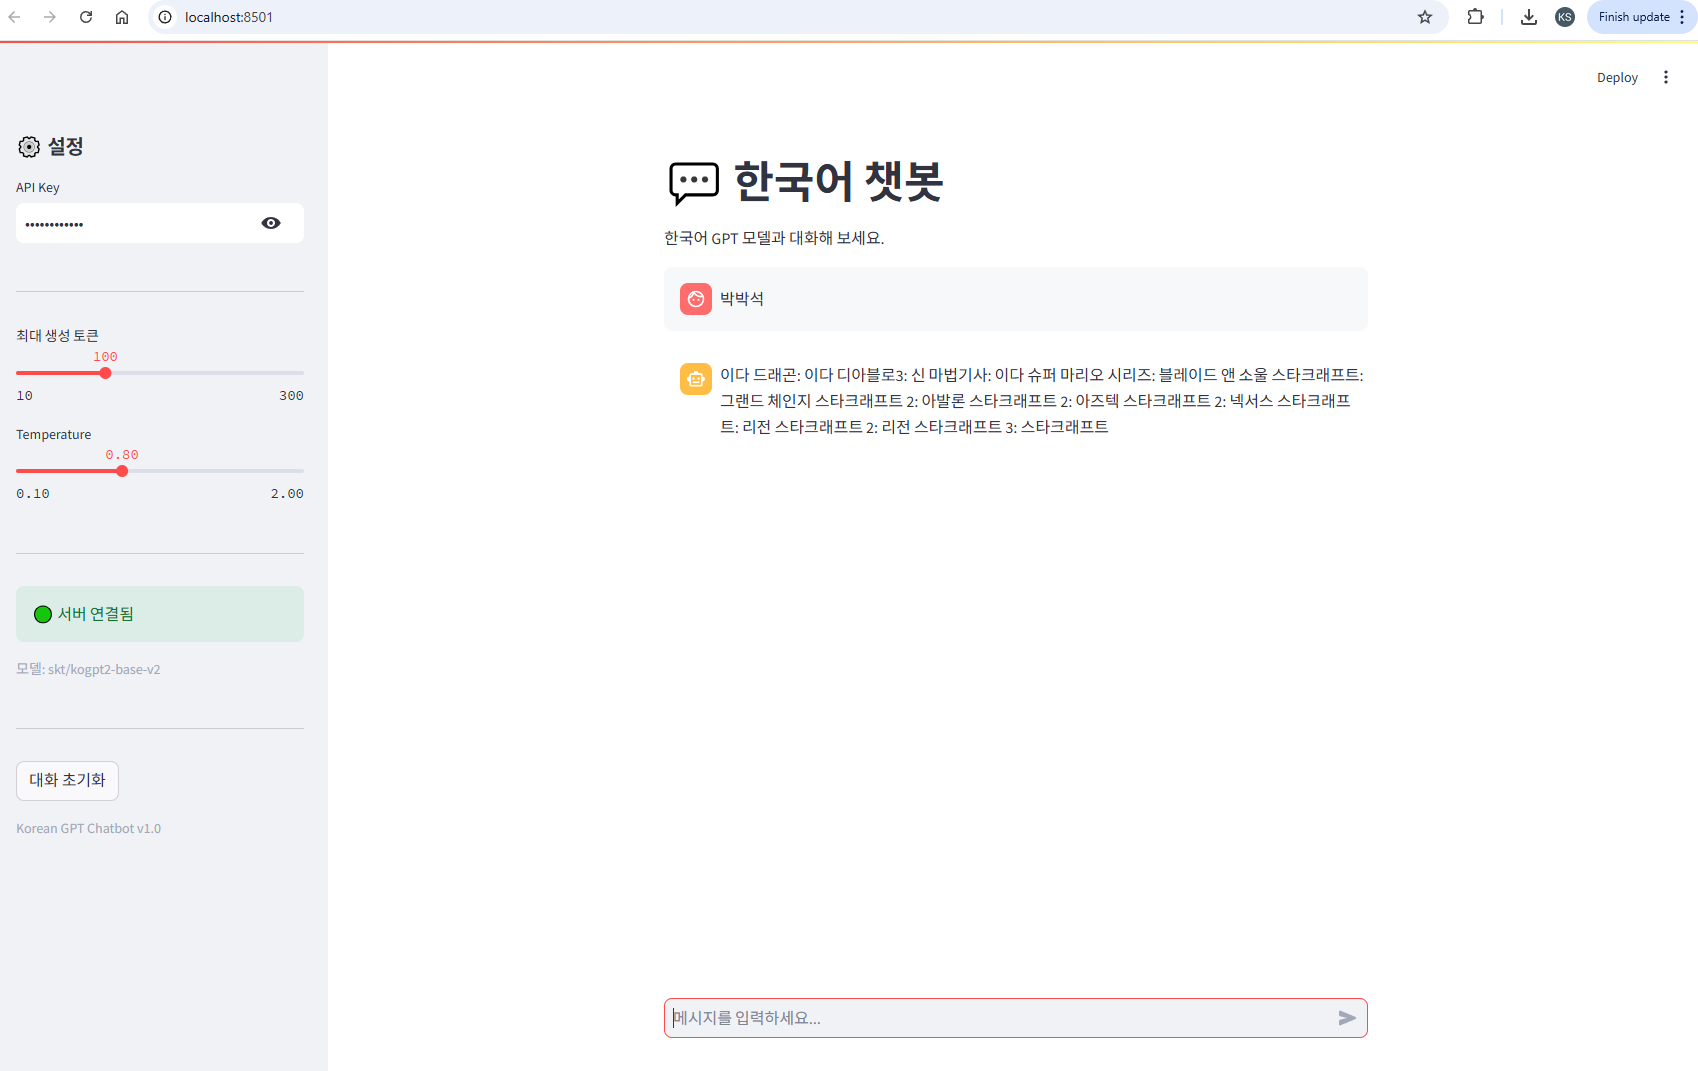

---

> **Day 8 예고**
>
> 지금까지 수행한 내용을 바탕을 자율 프로젝트를 수행합니다.  

### 과제 제출  
1. 테스트 1~4 실행 결과  
2. UI 테스트 1~4 실행 결과 (캡쳐)  
3. Day7 최종 체크포인트의 답변  
4. 회고

### 제출
[제출 링크](https://forms.gle/HuSDt9cnpCqqUDJo8)

다음 내역을 MD 파일로 기록, 깃헙에 업로드하여 링크로 제출하시기 바랍니다  

1. 프로젝트 실행 내역 캡쳐와 설명
2. 각 섹션 체크포인트의 답변
3. 프로젝트 회고

수고하셨습니다!